<a href="https://githubtocolab.com/tannialhernandez/topicosAvanzadosAnalitica/blob/main/E10-TwitterAnalysis/E10_TwitterNetworkAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Twitter Network Analysis
This notebook contains a social network analysis mainly executed with the library of NetworkX. In detail, this dataset consists of 'circles' (or 'lists') from Twitter. Twitter data was crawled from public sources. The dataset includes node features (profiles), circles, and ego networks. The dataset can be found at this link: [Stanford Twitter Dataset](https://snap.stanford.edu/data/ego-Twitter.html).

## Import packages

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from random import randint

%matplotlib inline

## Analysis
The edges are loaded from the `data` folder and saved in a dataframe. Each edge is a new row and for each edge there is a `start_node` and an `end_node` column

In [ ]:
twitter = pd.read_csv(
    "https://snap.stanford.edu/data/twitter_combined.txt.gz",
    compression="gzip",
    sep=" ",
    names=["start_node", "end_node"],
)
twitter = twitter.iloc[:80000]

The graph is created from the `twitter` dataframe of the edges:

In [ ]:
G = nx.from_pandas_edgelist(twitter, "start_node", "end_node")

## Visualizing the graph

Let's start our exploration by visualizing the graph. Visualization plays a
central role in exploratory data analysis to help get a qualitative feel for
the data.

Since we don't have any real sense of structure in the data, let's start by
viewing the graph with `random_layout`, which is among the fastest of the layout
functions.

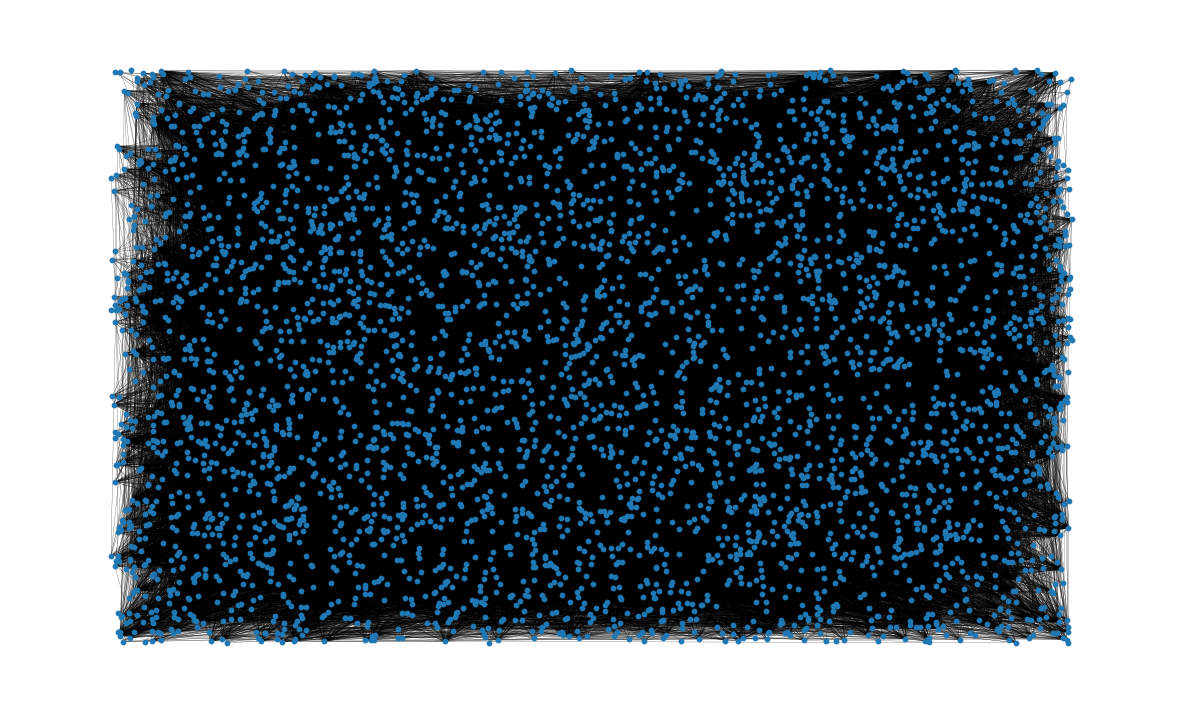

In [ ]:
fig, ax = plt.subplots(figsize=(15, 9))
ax.axis("off")
plot_options = {"node_size": 10, "with_labels": False, "width": 0.15}
nx.draw_networkx(G, pos=nx.random_layout(G), ax=ax, **plot_options)

Do we need more or less information (nodes or edges) from the graph to do the analysis? Let's check `spring_layout` and continue analysis...

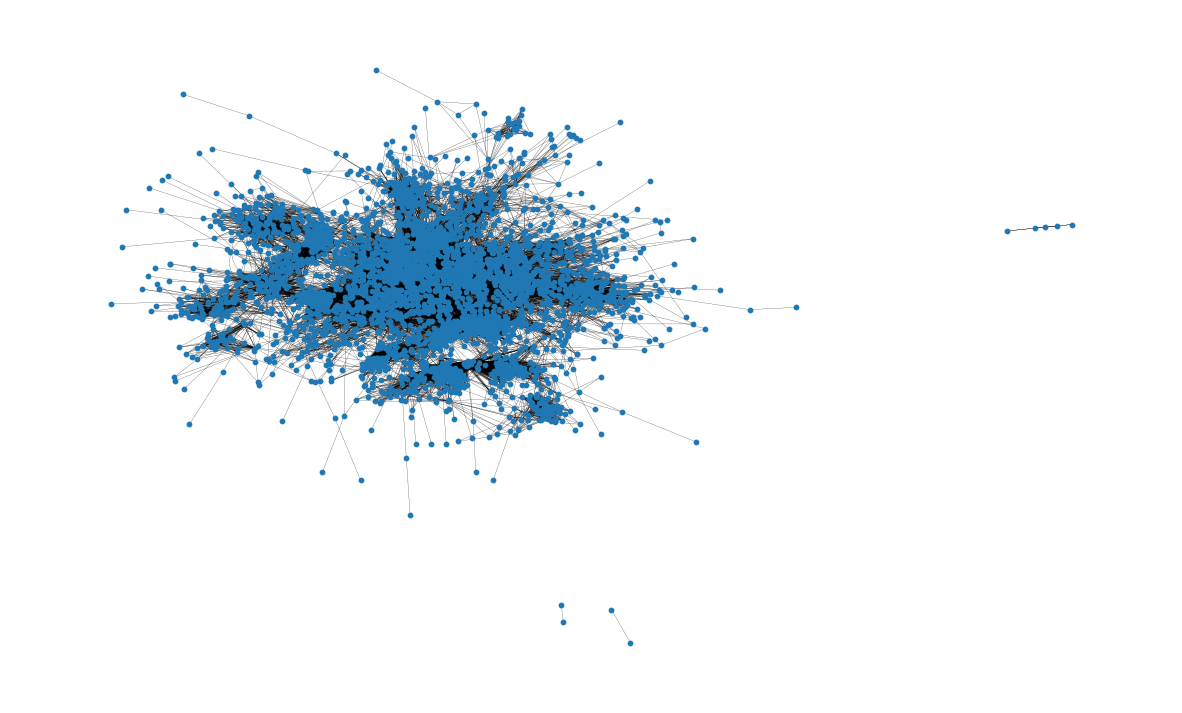

In [ ]:
pos = nx.spring_layout(G, iterations=15, seed=1721)
fig, ax = plt.subplots(figsize=(15, 9))
ax.axis("off")
nx.draw_networkx(G, pos=pos, ax=ax, **plot_options)

What other information can we extract from this network? ... (check graphs metrics)

Total number of nodes and edges in network:

In [ ]:
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 4316
Number of edges: 58270


On average, each node is conected to 27 other nodes.

In [ ]:
print("Average degree:", np.mean(list(dict(G.degree()).values())))

Average degree: 27.00185356811863


Shortest path length for all pairs of nodes in the network and print the first ten:

In [ ]:
shortest_path_lengths = dict(nx.all_pairs_shortest_path_length(G))
print(list(shortest_path_lengths.keys())[:10])
print(list(shortest_path_lengths.values())[:10])

[214328887, 34428380, 17116707, 28465635, 380580781, 18996905, 221036078, 153460275, 107830991, 17868918]
[{214328887: 0, 34428380: 1, 56860418: 1, 463952369: 1, 157829215: 1, 158419434: 1, 14925700: 1, 358775055: 1, 380580781: 1, 112939321: 1, 155661154: 1, 123371682: 1, 86221475: 1, 265077741: 1, 307458983: 1, 252770012: 1, 254839786: 1, 279787626: 1, 151338729: 1, 74107696: 1, 195475105: 1, 153226312: 1, 19493072: 1, 145845459: 1, 274153775: 1, 103598216: 1, 8088112: 1, 221036078: 1, 149538028: 1, 26929220: 1, 6581292: 1, 83943787: 1, 37699718: 1, 204140367: 1, 204317520: 1, 107830991: 1, 276706356: 1, 400689940: 1, 222261763: 1, 17868918: 1, 29911100: 1, 46209291: 1, 28465635: 1, 406628822: 1, 439788025: 1, 21548772: 1, 229425177: 1, 236184723: 1, 18951737: 1, 187773078: 1, 276577539: 1, 69592091: 1, 430268163: 1, 529007327: 1, 88323281: 1, 134940306: 1, 250340951: 1, 270449528: 1, 276308596: 1, 259842341: 1, 124528830: 1, 375317198: 1, 196327549: 1, 297801196: 1, 153460275: 1, 728

Length of shortest path between nodes 214328887 and 17116707

In [ ]:
shortest_path_lengths[214328887][17116707]  # Length of shortest path between nodes 214328887 and 17116707

1

I tried to use this line of code, but I got the error “Found infinite path length because the graph is not connected” because not all nodes are conected, so I asked chat gpt and it told me that I should work with a larger context.

> diameter = max(nx.eccentricity(G, sp=shortest_path_lengths).values())



In [ ]:
largest_cc = max(nx.connected_components(G), key=len)
# Creates the corresponding subgraph
G_sub = G.subgraph(largest_cc)
# Calculates the shortest distances ONLY in that subgraph.
sp_sub = dict(nx.all_pairs_shortest_path_length(G_sub))
# Calculates eccentricity and diameter
diameter = max(nx.eccentricity(G_sub, sp=sp_sub).values())
print(diameter)

16


In order to connect from one node to any other one we would have to traverse 16 edges or fewer

In order to reach from one node to another node, roughly 4.8 edges will be traversed on average.

In [ ]:
# Compute the average shortest path length for each node
average_path_lengths = [
    np.mean(list(spl.values())) for spl in shortest_path_lengths.values()
]
# The average over all nodes
np.mean(average_path_lengths)

np.float64(4.837700405033223)

Text(0, 0.5, 'Frequency (%)')

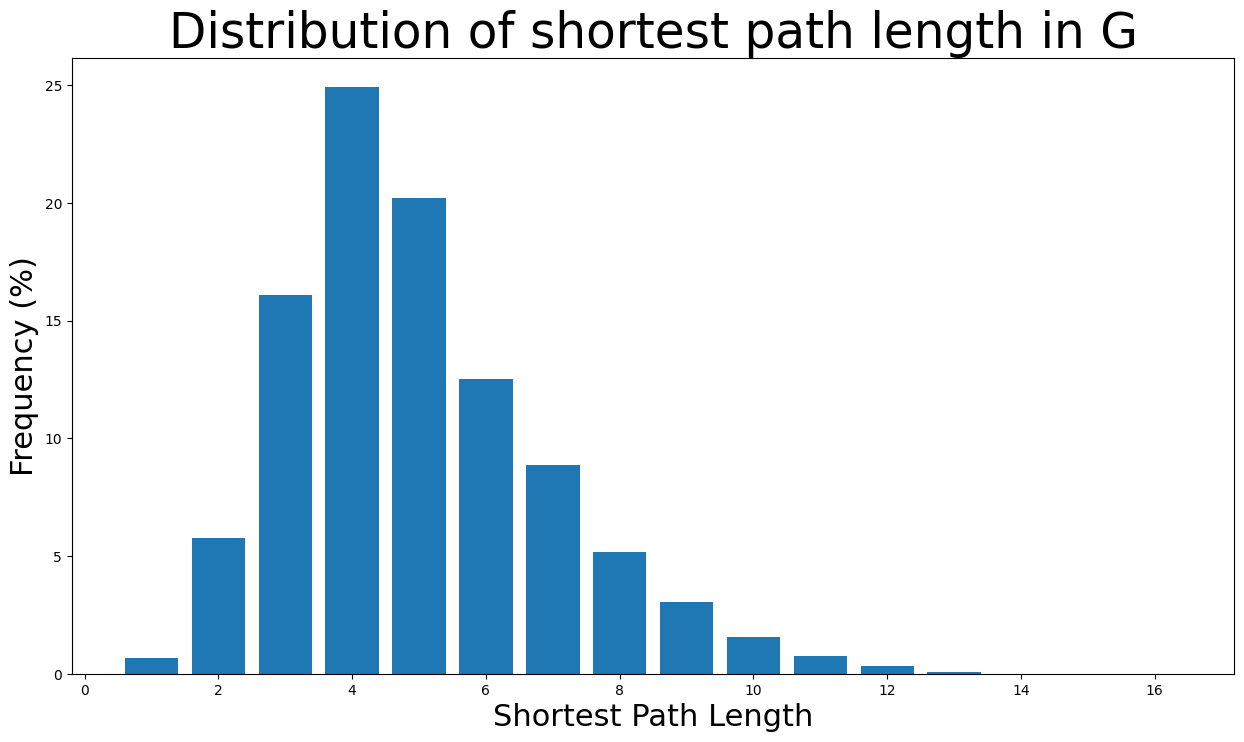

In [ ]:
# We know the maximum shortest path length (the diameter), so create an array
# to store values from 0 up to (and including) diameter
path_lengths = np.zeros(diameter + 1, dtype=int)

# Extract the frequency of shortest path lengths between two nodes
for pls in shortest_path_lengths.values():
    pl, cnts = np.unique(list(pls.values()), return_counts=True)
    path_lengths[pl] += cnts

# Express frequency distribution as a percentage (ignoring path lengths of 0)
freq_percent = 100 * path_lengths[1:] / path_lengths[1:].sum()

# Plot the frequency distribution (ignoring path lengths of 0) as a percentage
fig, ax = plt.subplots(figsize=(15, 8))
ax.bar(np.arange(1, diameter + 1), height=freq_percent)
ax.set_title(
    "Distribution of shortest path length in G", fontdict={"size": 35}, loc="center"
)
ax.set_xlabel("Shortest Path Length", fontdict={"size": 22})
ax.set_ylabel("Frequency (%)", fontdict={"size": 22})

The density is much less than 1, indicating the sparsity of the network.

In [ ]:
nx.density(G)

0.0062576717423218145

The network G has 7 connected components. There are 7 independent groups of nodes in the network, where there is no path connecting a node of one group with a node of another group. This explains the above error.

In [ ]:
nx.number_connected_components(G)

7

We look for the nodes with the 8 highest degree centralities (the percentage of the network to which the node is connected).

In [ ]:
degree_centrality = nx.centrality.degree_centrality(
    G
)  # save results in a variable to use again
(sorted(degree_centrality.items(), key=lambda item: item[1], reverse=True))[:8]

[(48485771, 0.07022016222479723),
 (5442012, 0.06813441483198146),
 (3359851, 0.06581691772885284),
 (40981798, 0.06257242178447277),
 (43003845, 0.0593279258400927),
 (34428380, 0.056315179606025494),
 (22462180, 0.05608342989571263),
 (15913, 0.055851680185399766)]

That means that node 48485771 has the highest degree centrality with
7%, meaning that this twiter user has around 7% of followers of the whole network.

Now we can also see the number of neighbors for the nodes with the highest degree centralities:

In [ ]:
(sorted(G.degree, key=lambda item: item[1], reverse=True))[:8]

[(48485771, 303),
 (5442012, 294),
 (3359851, 284),
 (40981798, 270),
 (43003845, 256),
 (34428380, 243),
 (22462180, 242),
 (15913, 241)]

Now the distribution of degree centralities will be plotted:

Text(0, 0.5, 'Counts')

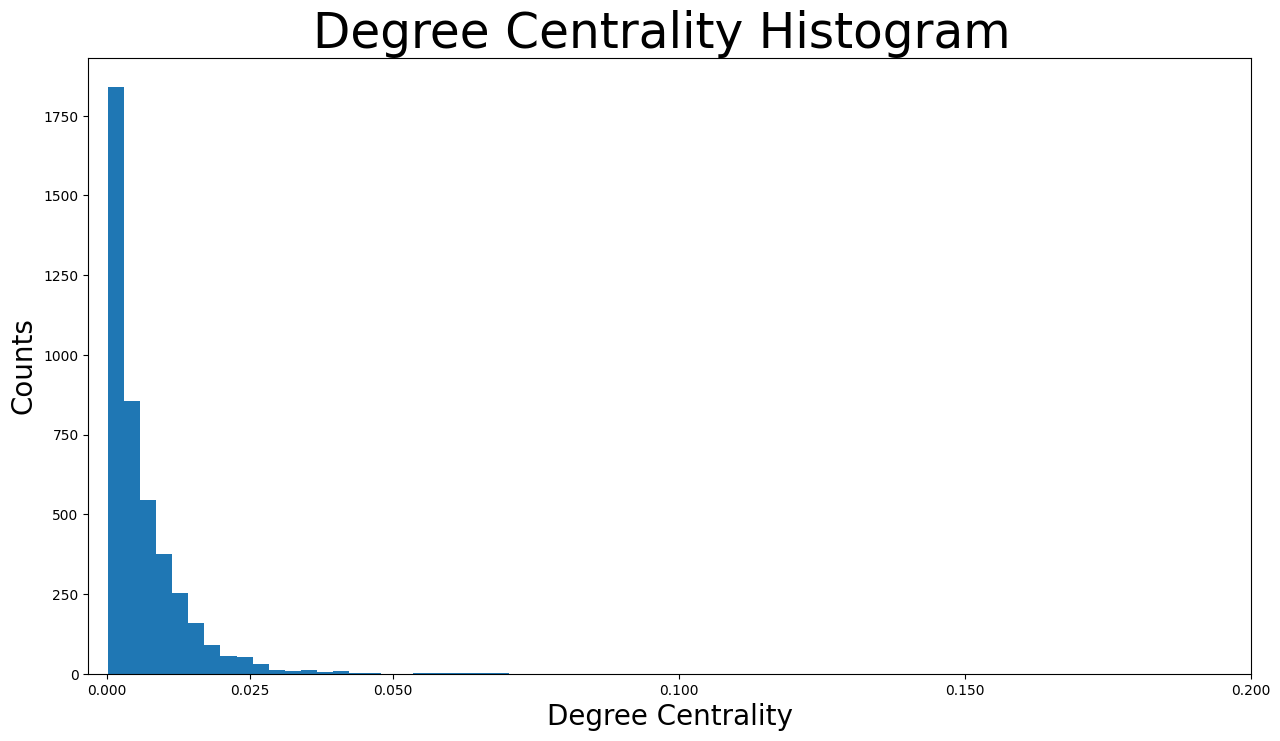

In [ ]:
plt.figure(figsize=(15, 8))
plt.hist(degree_centrality.values(), bins=25)
plt.xticks(ticks=[0, 0.025, 0.05, 0.1, 0.15, 0.2])  # set the x axis ticks
plt.title("Degree Centrality Histogram ", fontdict={"size": 35}, loc="center")
plt.xlabel("Degree Centrality", fontdict={"size": 20})
plt.ylabel("Counts", fontdict={"size": 20})

Users with highest degree centralities from the size of their nodes:

(np.float64(-0.6459476724267006),
 np.float64(1.1564022675156593),
 np.float64(-1.0558947339653968),
 np.float64(0.7013561144471169))

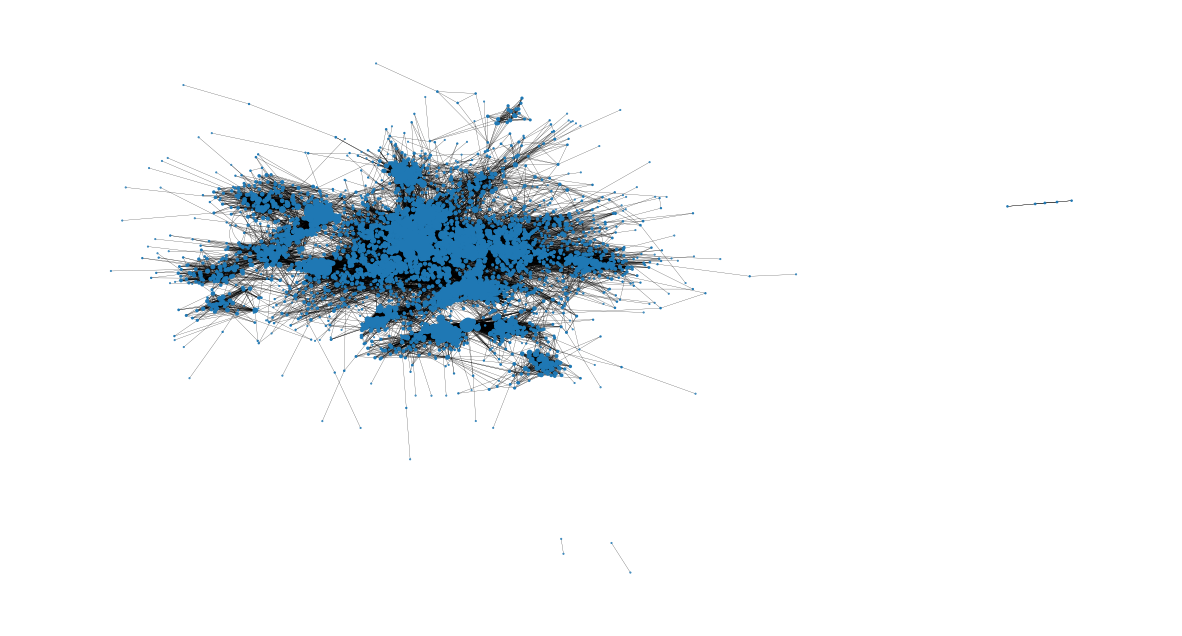

In [ ]:
node_size = [
    v * 1000 for v in degree_centrality.values()
]  # set up nodes size for a nice graph representation
plt.figure(figsize=(15, 8))
nx.draw_networkx(G, pos=pos, node_size=node_size, with_labels=False, width=0.15)
plt.axis("off")

# Betweenness Centrality

Nodes with the 8 highest interrelatedness centralities are calculated, the users that act as a bridge to many users, influencing information transmission.

In [ ]:
betweenness_centrality = nx.centrality.betweenness_centrality(
    G
)  # save results in a variable to use again
(sorted(betweenness_centrality.items(), key=lambda item: item[1], reverse=True))[:8]

[(6207392, 0.1725645640056724),
 (3359851, 0.15443758920551148),
 (783214, 0.0975291202117271),
 (41716273, 0.09272687817377762),
 (17093617, 0.09073724589851986),
 (27634404, 0.08587007531097253),
 (15666380, 0.07953763787324364),
 (48485771, 0.05738734697388068)]

Nodes 6207392 and 3359851 have the highest betweenness centrality, meaning it lies part of the total shortest paths between other nodes.

Text(0, 0.5, 'Counts')

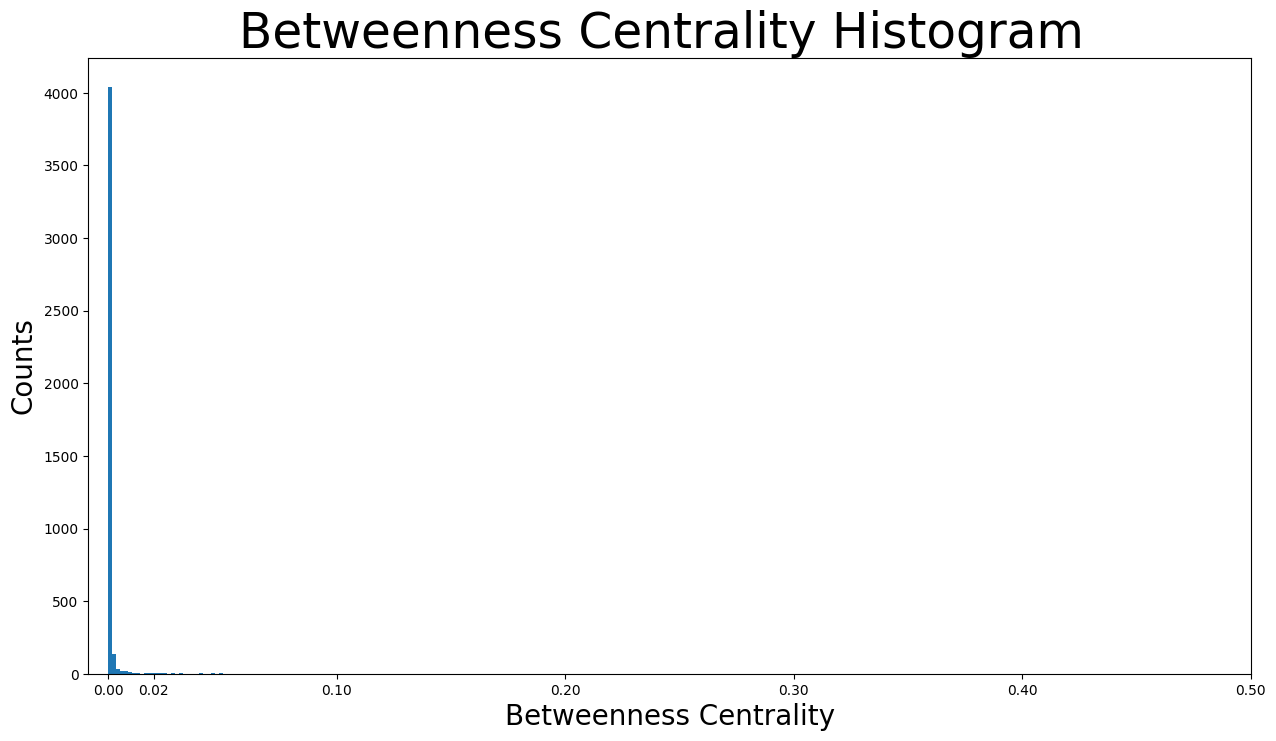

In [ ]:
plt.figure(figsize=(15, 8))
plt.hist(betweenness_centrality.values(), bins=100)
plt.xticks(ticks=[0, 0.02, 0.1, 0.2, 0.3, 0.4, 0.5])  # set the x axis ticks
plt.title("Betweenness Centrality Histogram ", fontdict={"size": 35}, loc="center")
plt.xlabel("Betweenness Centrality", fontdict={"size": 20})
plt.ylabel("Counts", fontdict={"size": 20})

We can also get an image on the nodes with the highest betweenness centralities and where they are located in the network. It is clear that they are the bridges from one community to another:

(np.float64(-0.6459476724267006),
 np.float64(1.1564022675156593),
 np.float64(-1.0558947339653968),
 np.float64(0.7013561144471169))

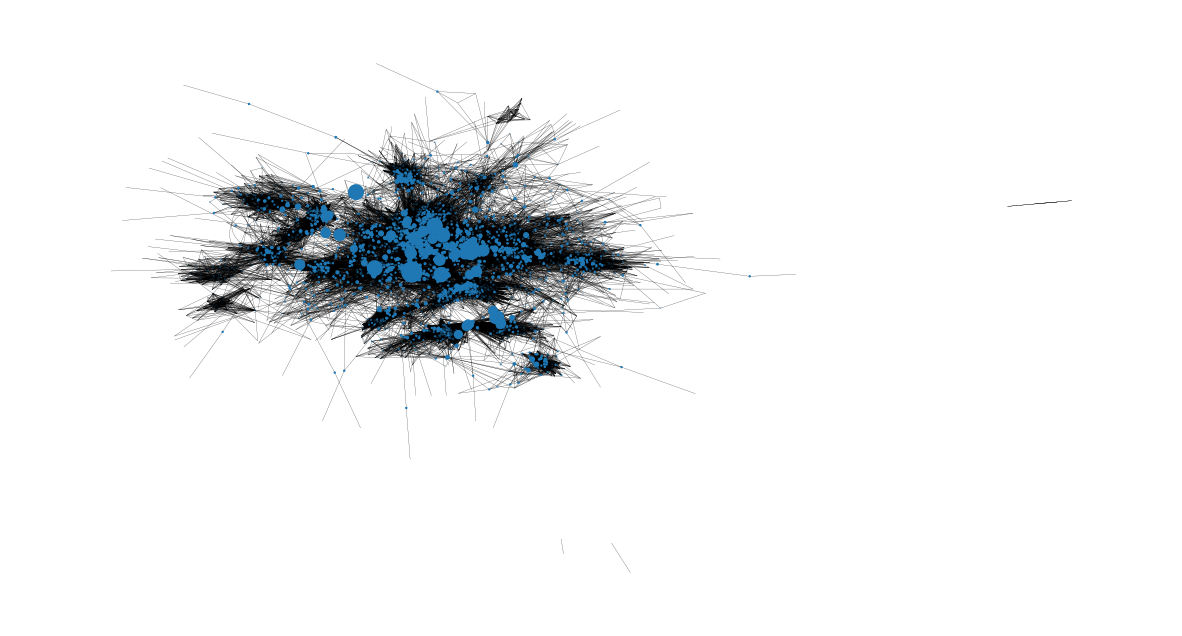

In [ ]:
node_size = [
    v * 1200 for v in betweenness_centrality.values()
]  # set up nodes size for a nice graph representation
plt.figure(figsize=(15, 8))
nx.draw_networkx(G, pos=pos, node_size=node_size, with_labels=False, width=0.15)
plt.axis("off")

# Closeness Centrality

Nodes with the highest proximity centralities are those with the closest proximity to all other nodes in the network, the higher the proximity centrality of the closer it is to the center of the network.

In [ ]:
closeness_centrality = nx.centrality.closeness_centrality(
    G
)  # save results in a variable to use again
(sorted(closeness_centrality.items(), key=lambda item: item[1], reverse=True))[:8]

[(3359851, 0.3174907000782523),
 (15234657, 0.2989200839846593),
 (48485771, 0.2947102540271258),
 (7860742, 0.293730499193259),
 (15666380, 0.2907448655999966),
 (20880546, 0.29061735524303445),
 (3829151, 0.2868847706962951),
 (115485051, 0.2850950836856413)]

Also, the average distance of a particular node
 to any other node can be found easily with the formula:

In [ ]:
1 / closeness_centrality[3359851]

3.149698557323187

The distance from node 3359851 to a random node is around two hops

Furthermore, the distribution of the closeness centralities:

Text(0, 0.5, 'Counts')

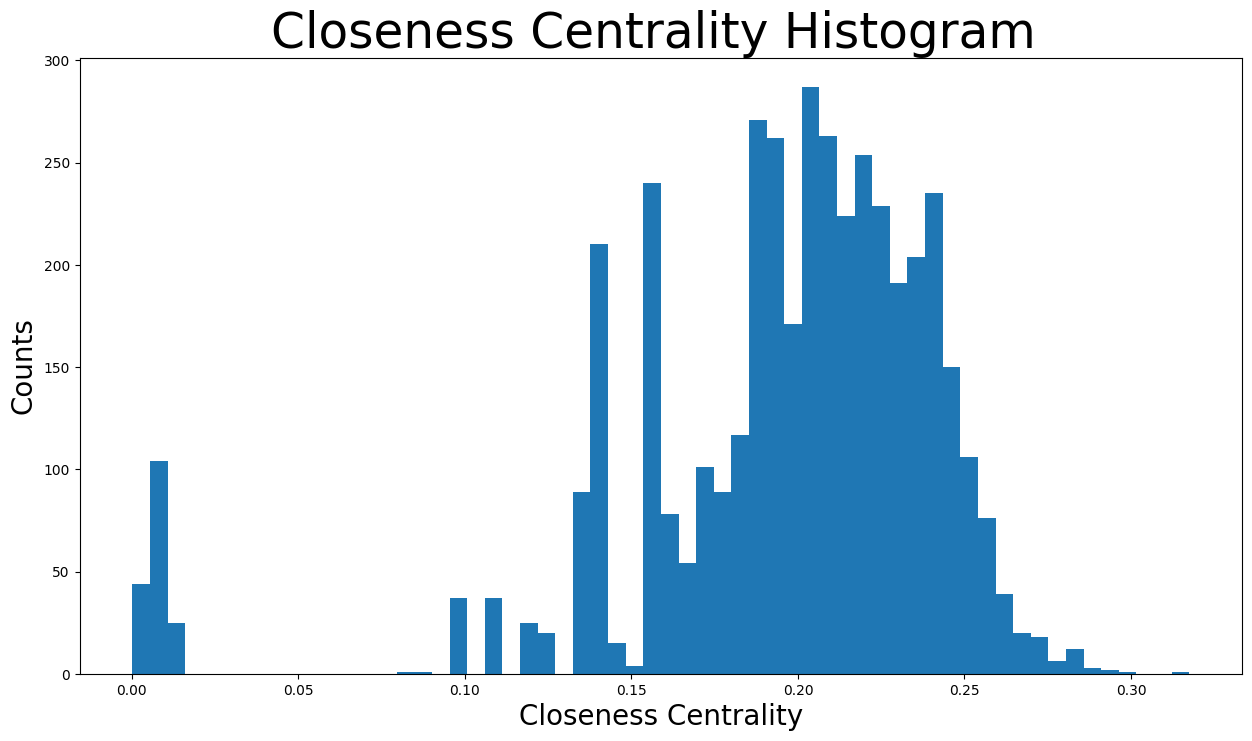

In [ ]:
plt.figure(figsize=(15, 8))
plt.hist(closeness_centrality.values(), bins=60)
plt.title("Closeness Centrality Histogram ", fontdict={"size": 35}, loc="center")
plt.xlabel("Closeness Centrality", fontdict={"size": 20})
plt.ylabel("Counts", fontdict={"size": 20})

(np.float64(-0.6459476724267006),
 np.float64(1.1564022675156593),
 np.float64(-1.0558947339653968),
 np.float64(0.7013561144471169))

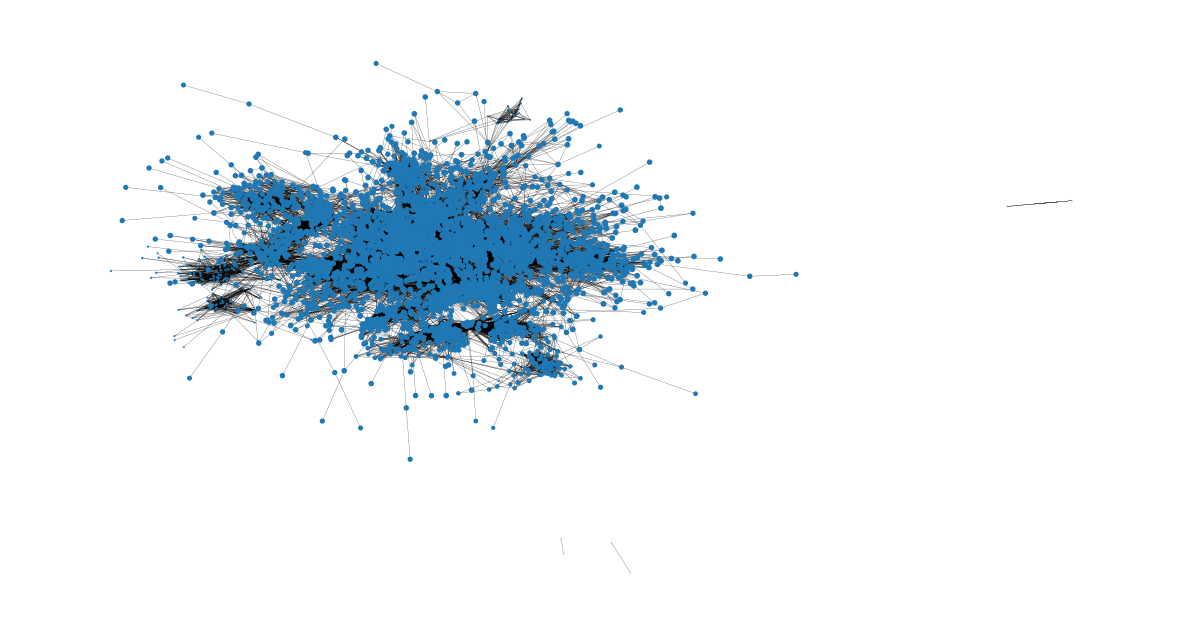

In [ ]:
node_size = [
    v * 50 for v in closeness_centrality.values()
]  # set up nodes size for a nice graph representation
plt.figure(figsize=(15, 8))
nx.draw_networkx(G, pos=pos, node_size=node_size, with_labels=False, width=0.15)
plt.axis("off")

# Eigenvector Centrality

Eigenvector centrality is the metric to show how connected a node is to other important nodes in the network. A high eigenvector centrality means that the node is connected to other nodes who themselves have high eigenvector centralities.

In [ ]:
eigenvector_centrality = nx.centrality.eigenvector_centrality(
    G
)  # save results in a variable to use again
(sorted(eigenvector_centrality.items(), key=lambda item: item[1], reverse=True))[:10]

[(40981798, 0.15363590744821665),
 (43003845, 0.1507372702636457),
 (22462180, 0.14898138833635383),
 (34428380, 0.14836888505482648),
 (153226312, 0.11747403879993272),
 (270449528, 0.11544891170259039),
 (83943787, 0.11509706228160357),
 (17868918, 0.11470184783932444),
 (151338729, 0.11429285736480958),
 (279787626, 0.1140975626333083)]

In [ ]:
high_eigenvector_centralities = (
    sorted(eigenvector_centrality.items(), key=lambda item: item[1], reverse=True)
)[
    1:10
]  # 2nd to 10th nodes with heighest eigenvector centralities
high_eigenvector_nodes = [
    tuple[0] for tuple in high_eigenvector_centralities
]  # set list as [43003845, 22462180, 34428380, 153226312, 270449528, 83943787, 17868918, 151338729, 279787626]
neighbors_40981798 = [n for n in G.neighbors(40981798)]  # list with all nodes connected to 40981798
all(
    item in neighbors_40981798 for item in high_eigenvector_nodes
)  # check if items in list high_eigenvector_nodes exist in list neighbors_40981798

True

Text(0, 0.5, 'Counts')

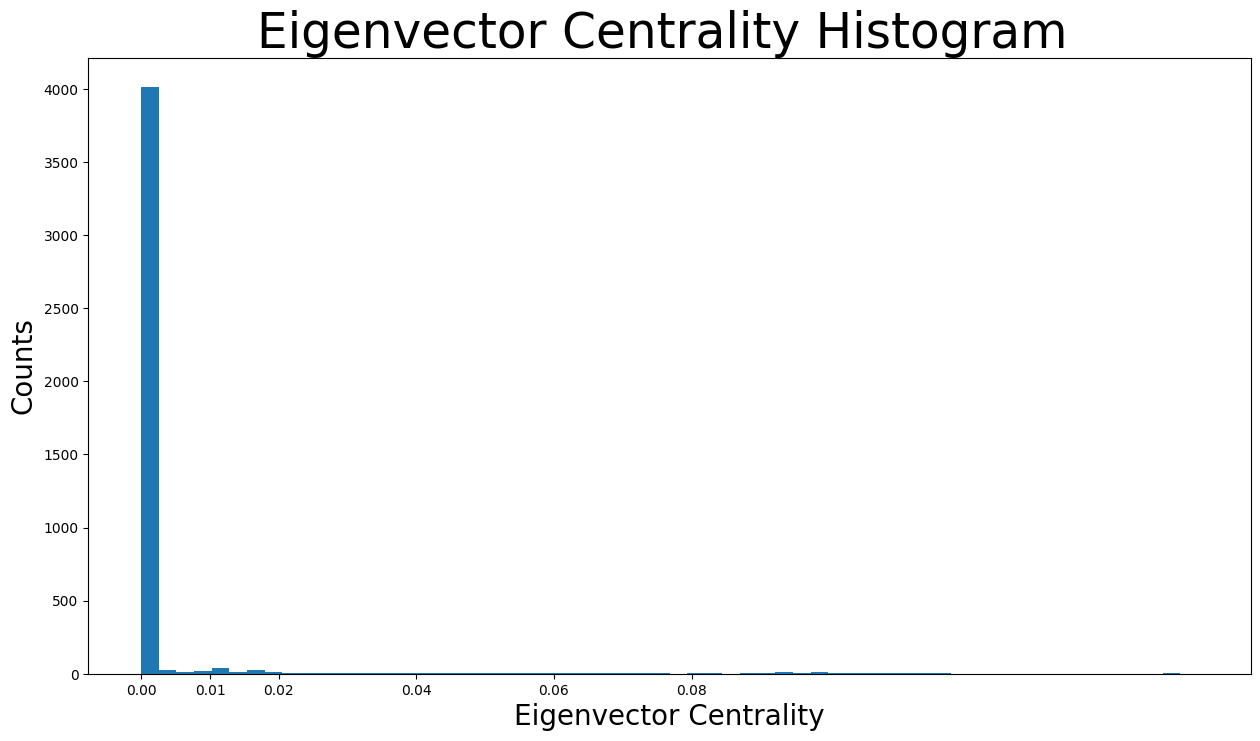

In [ ]:
plt.figure(figsize=(15, 8))
plt.hist(eigenvector_centrality.values(), bins=60)
plt.xticks(ticks=[0, 0.01, 0.02, 0.04, 0.06, 0.08])  # set the x axis ticks
plt.title("Eigenvector Centrality Histogram ", fontdict={"size": 35}, loc="center")
plt.xlabel("Eigenvector Centrality", fontdict={"size": 20})
plt.ylabel("Counts", fontdict={"size": 20})

Now we can identify the eigenvector centralities of nodes based on their size in the following representation:

(np.float64(-0.6459476724267006),
 np.float64(1.1564022675156593),
 np.float64(-1.0558947339653968),
 np.float64(0.7013561144471169))

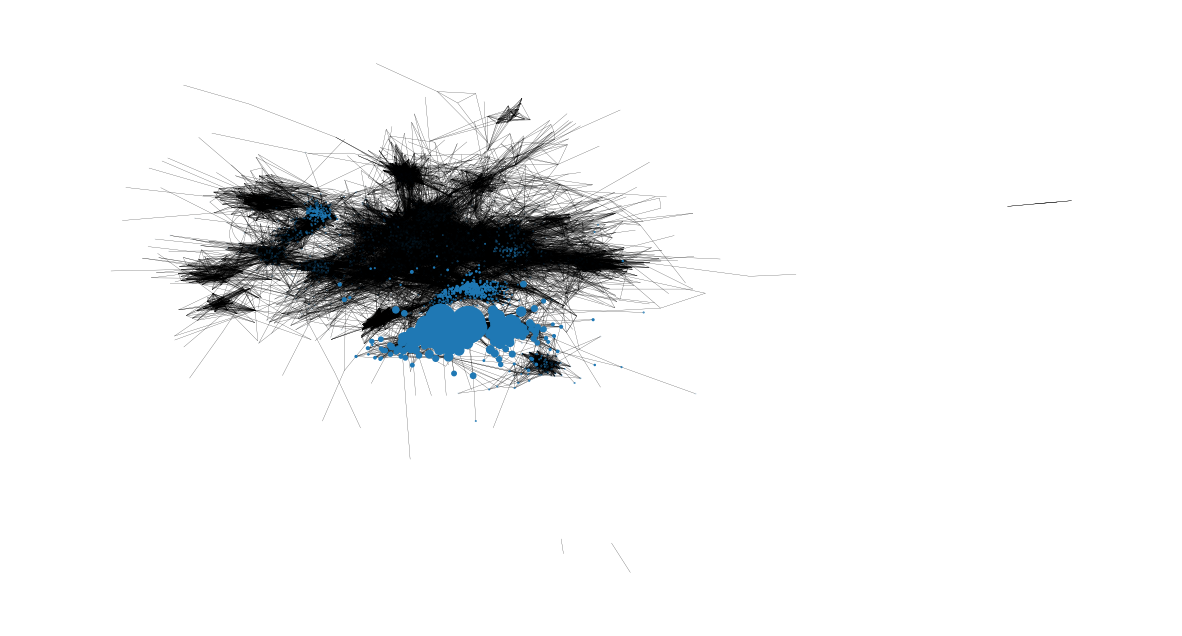

In [ ]:
node_size = [
    v * 4000 for v in eigenvector_centrality.values()
]  # set up nodes size for a nice graph representation
plt.figure(figsize=(15, 8))
nx.draw_networkx(G, pos=pos, node_size=node_size, with_labels=False, width=0.15)
plt.axis("off")

# Clustering Effects

The average clustering coefficient is the average of clustering coefficients of all the nodes

In [ ]:
nx.average_clustering(G)

0.4949716847236492

Now the clustering coefficient distribution will be displayed:

Text(0, 0.5, 'Counts')

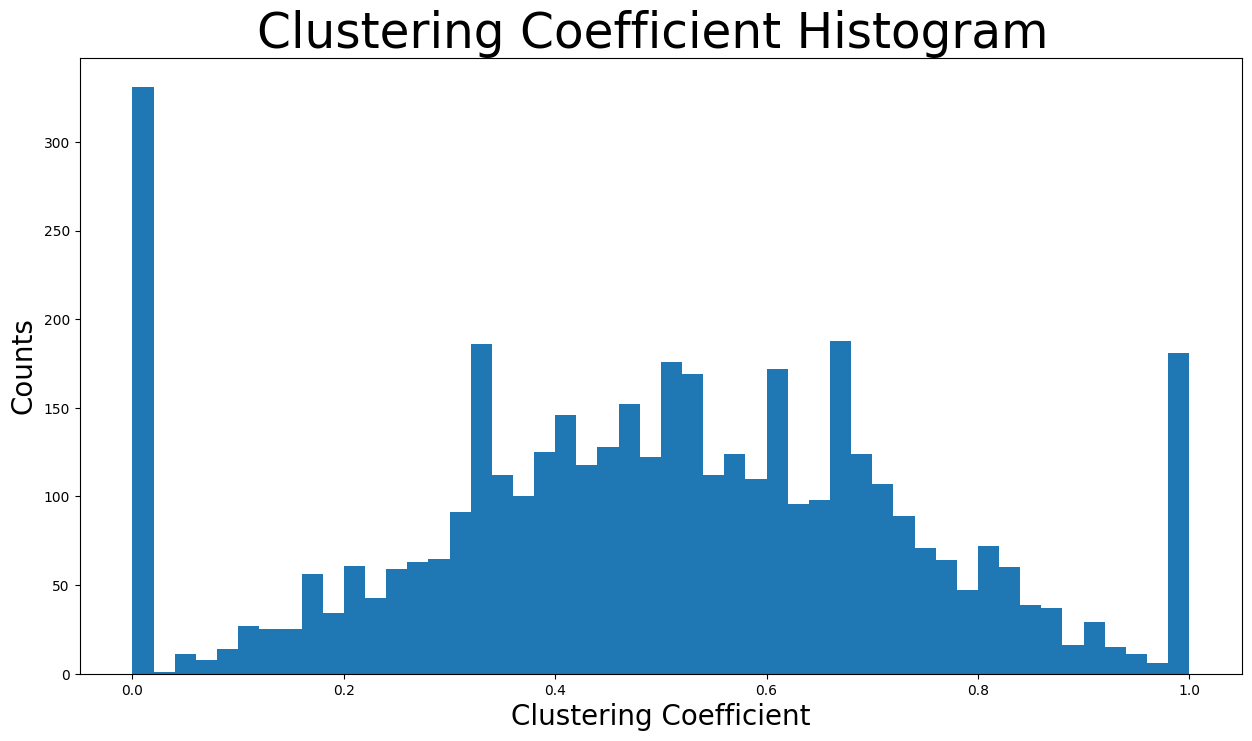

In [ ]:
plt.figure(figsize=(15, 8))
plt.hist(nx.clustering(G).values(), bins=50)
plt.title("Clustering Coefficient Histogram ", fontdict={"size": 35}, loc="center")
plt.xlabel("Clustering Coefficient", fontdict={"size": 20})
plt.ylabel("Counts", fontdict={"size": 20})

The number of unique triangles in the network are found next:

In [ ]:
triangles_per_node = list(nx.triangles(G).values())
sum(
    triangles_per_node
) / 3  # divide by 3 because each triangle is counted once for each node

465759.0

Now the average number of triangles that a node is a part of:

In [ ]:
np.mean(triangles_per_node)

np.float64(323.7435125115848)

Due to having some nodes that belong to a great many triangles, the metric of median will give us a better understanding:

In [ ]:
np.median(triangles_per_node)

np.float64(71.0)

The majority of users participate in relatively few triangles (little formation of closed groups around them), while a few users are in a very high number of triangles

# Bridges

In [ ]:
nx.has_bridges(G)

True

Actually, there are bridges in the network. Now the edges that are bridges will be saved in a list and the number of them is printed:

In [ ]:
bridges = list(nx.bridges(G))
len(bridges)

209

In [ ]:
local_bridges = list(nx.local_bridges(G, with_span=False))
len(local_bridges)

987

(np.float64(-0.6459476724267006),
 np.float64(1.1564022675156593),
 np.float64(-1.0558947339653968),
 np.float64(0.7013561144471169))

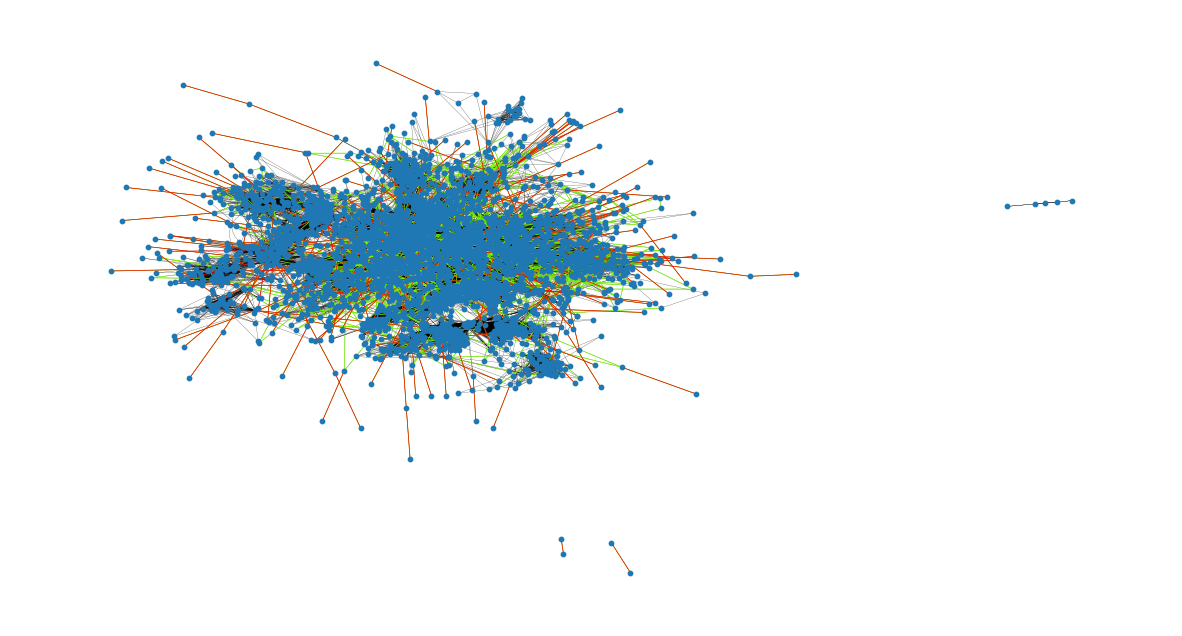

In [ ]:
plt.figure(figsize=(15, 8))
nx.draw_networkx(G, pos=pos, node_size=10, with_labels=False, width=0.15)
nx.draw_networkx_edges(
    G, pos, edgelist=local_bridges, width=0.5, edge_color="lawngreen"
)  # green color for local bridges
nx.draw_networkx_edges(
    G, pos, edgelist=bridges, width=0.5, edge_color="r"
)  # red color for bridges
plt.axis("off")

# Assortativity

The assortativity in terms of nodes degrees is found with two ways:

In [ ]:
nx.degree_assortativity_coefficient(G)

0.07572773506976808

In [ ]:
nx.degree_pearson_correlation_coefficient(
    G
)  # use the potentially faster scipy.stats.pearsonr function

0.07572773506976577

In fact, the assortativity coefficient is the Pearson correlation coefficient of degree between pairs of linked nodes. That means that it takes values from
-1 to 1. The assortativity coefficient is around 0.07, which is almost 0. That means that the network is almost non-assortative, and we cannot correlate linked nodes based on their degrees.

# Network Communities

A community is a group of nodes, so that nodes inside the group are connected with many more edges than between groups. Two different algorithms will be used for communities detection in this network

In [ ]:
from random import randint

colors = dict()
counter = 0
for com in nx.community.label_propagation_communities(G):
    color = "#%06X" % randint(0, 0xFFFFFF)  # color random
    counter += 1
    for node in com:
        colors[node] = color  # cada nodo recibe su color

counter

88

In detail, 88 communities were detected. Now the communities are showcased in the graph. Each community is depicted with a different color and its nodes are usually located close to each other:

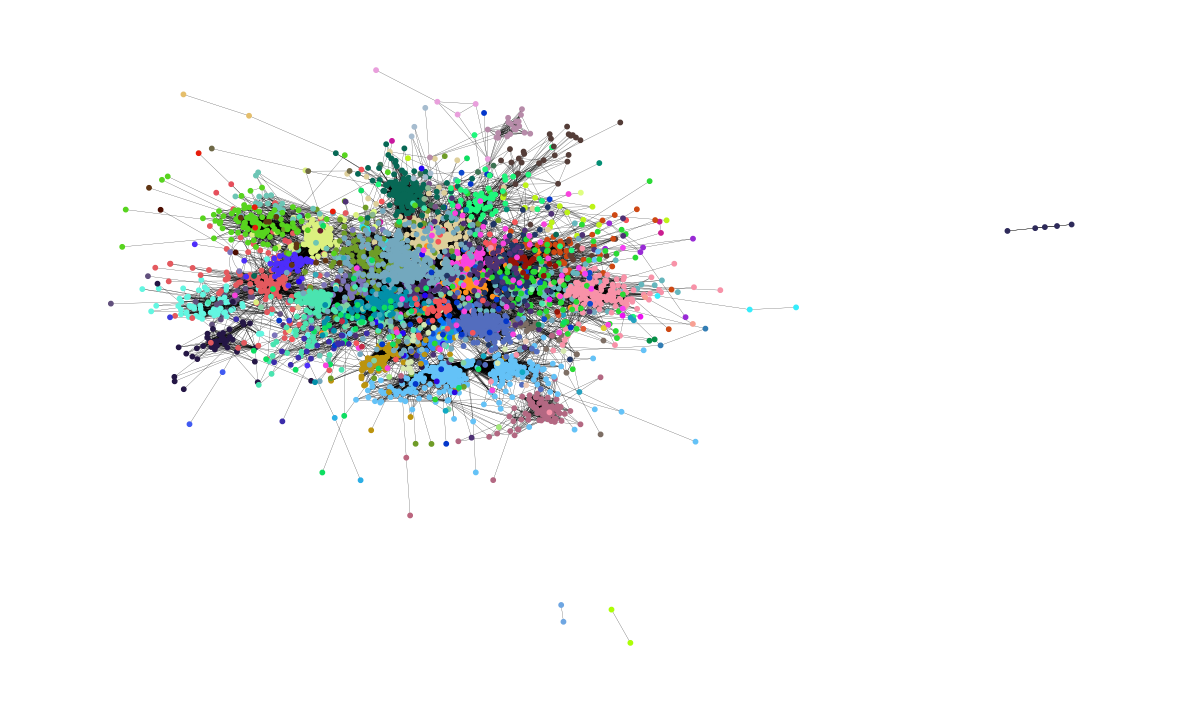

In [ ]:
node_colors = [colors[node] for node in G.nodes()]
plt.figure(figsize=(15, 9))
plt.axis("off")
nx.draw_networkx(
    G, pos=pos, node_size=10, with_labels=False, width=0.15, node_color=node_colors
)

In [ ]:
largest_cc = max(nx.connected_components(G), key=len)
Gcc = G.subgraph(largest_cc).copy()

# Ahora sí puedes aplicar asyn_fluidc
colors = {}
for com in nx.community.asyn_fluidc(Gcc, 8, seed=0):
    color = "#%06X" % randint(0, 0xFFFFFF)
    for node in com:
        colors[node] = color

# Colorea solo los nodos de Gcc, o asigna un color especial para los que no están en Gcc
node_colors = [colors.get(node, "#bbbbbb") for node in G.nodes()]

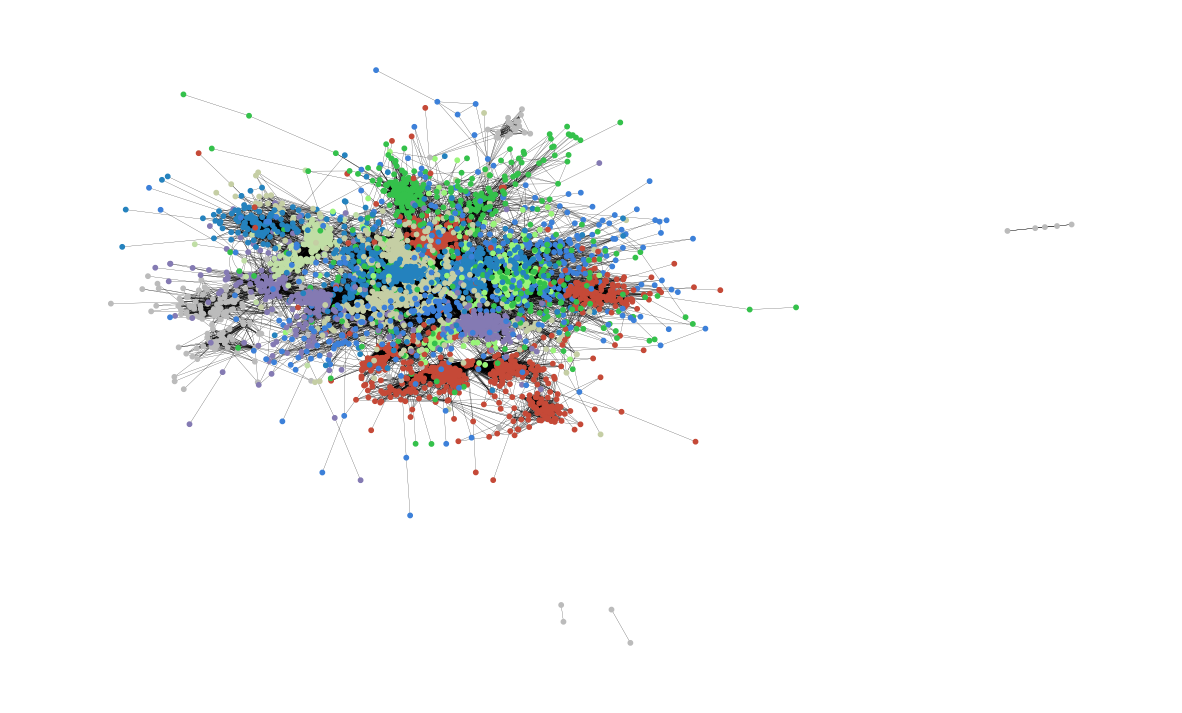

In [ ]:
node_colors = [colors.get(node, '#bbbbbb') for node in G.nodes()]
plt.figure(figsize=(15, 9))
plt.axis("off")
nx.draw_networkx(
    G, pos=pos, node_size=10, with_labels=False, width=0.15, node_color=node_colors
)